In [1]:
import numpy as np

In [3]:
import pandas as pd

In [29]:
df = pd.read_csv("raw_data.csv")
# df[["name","age","country","gender","income","id"]]
df2 = df.copy()
new_column = [col for col in df2.columns if col != "id"]+["id"]
# print(new_column)
df2 = df2[new_column]
df2 = df2.sort_values("income", ascending = False)
df2 = df2.fillna(0)
df2 = df2.reset_index(drop = True)
df2["tax"] = ["20%" if x>=55000 else "10%" for x in df2["income"]]

In [26]:
df2
df2.to_csv("clean_new_data.csv")

In [32]:
df2.groupby("gender")["income"].min()
df2.groupby("country")["income"].mean()
df2.groupby("country")["income"].max()

country
0         68000.0
Canada    62000.0
China     51000.0
India     73000.0
Mexico    45000.0
Spain         0.0
USA       62000.0
Name: income, dtype: float64

**Aggregation**

In [48]:
print(df2.groupby("country")["income"].agg(["mean","min", "max"]))
df2.groupby("country")["income"].agg(avg_income = "mean", min_income = "min", max_income = "max")
df2.groupby("country").agg({"income":"mean", "age":"min"})
df2.groupby("country").agg(avg_income = ("income","mean"), min_age = ("age","min"))

            mean      min      max
country                           
0        68000.0  68000.0  68000.0
Canada   62000.0  62000.0  62000.0
China    51000.0  51000.0  51000.0
India    73000.0  73000.0  73000.0
Mexico   45000.0  45000.0  45000.0
Spain        0.0      0.0      0.0
USA      55400.0  47000.0  62000.0


,avg_income,min_age
country,,
0,68000.0,38.0
Canada,62000.0,0.0
China,51000.0,27.0
India,73000.0,45.0
Mexico,45000.0,0.0
Spain,0.0,34.0
USA,55400.0,0.0


In [40]:
df2

,name,age,country,gender,income,id,tax
0,0,45.0,India,Female,73000.0,6,20%
1,Ahmed Khan,38.0,0,Male,68000.0,7,20%
2,Jane Smith,0.0,Canada,Female,62000.0,2,20%
3,Rachel Lee,29.0,USA,Female,62000.0,8,20%
4,Emily Davis,31.0,USA,0,58000.0,10,20%
5,John Doe,29.0,USA,Male,55000.0,1,20%
6,John Doe,29.0,USA,Male,55000.0,1,20%
7,Li Wei,27.0,China,Male,51000.0,5,10%
8,Alex,0.0,USA,Unknown,47000.0,3,10%
9,Carlos Ruiz,0.0,Mexico,Male,45000.0,9,10%


In [59]:
disk = {
    "country":["USA","USA","INDIA","INDIA"],
    "year" :[2020,2021,2020,2021],
    "sales" :[100,120,90,110],
    "profit" :[20,25,18,22]
}
df_for_rearange = pd.DataFrame(disk)
df_for_rearange_melt = df_for_rearange.melt(
    id_vars = ["country", "year"],
    value_vars = ["sales","profit"],
    var_name = "metrix",
    value_name = "value"
)
df_for_rearange_pivot = df_for_rearange_melt.pivot(
    index =["country","year"],
    columns ="metrix" ,
    values ="value"
)
print(df_for_rearange_melt)
print(df_for_rearange_pivot)

  country  year  metrix  value
0     USA  2020   sales    100
1     USA  2021   sales    120
2   INDIA  2020   sales     90
3   INDIA  2021   sales    110
4     USA  2020  profit     20
5     USA  2021  profit     25
6   INDIA  2020  profit     18
7   INDIA  2021  profit     22
metrix        profit  sales
country year               
INDIA   2020      18     90
        2021      22    110
USA     2020      20    100
        2021      25    120


**visualization**

<Axes: xlabel='age', ylabel='income'>

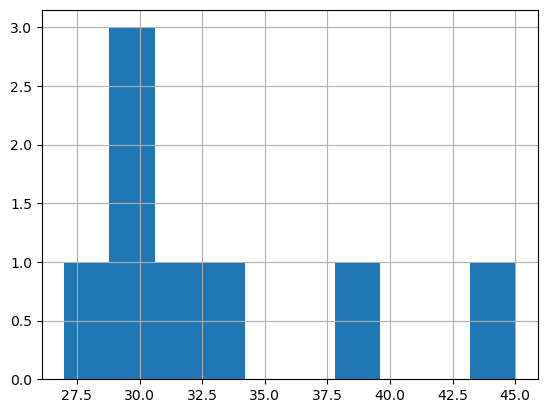

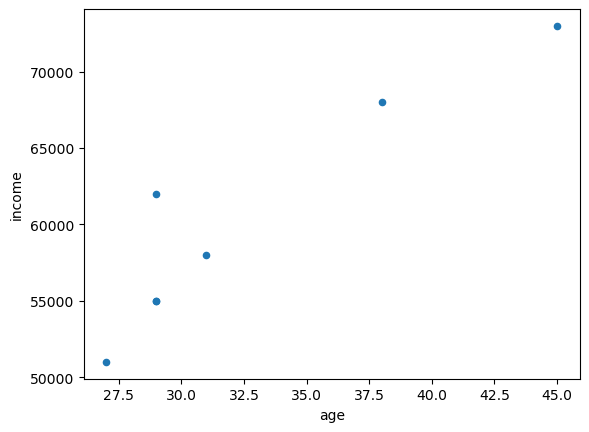

In [70]:
df
df["age"].hist()
df.plot(kind = "scatter", x="age", y = "income")

**MERGE**

In [80]:
disk2 = {
    "customer_id": [1,2,3,4],
    "name": ["Seyam","U","Kam","Labib"]
}
disk3 = {
    "customer_id": [1,2,3,5],
    "oder_id":[112,442,53,53]
}
customer = pd.DataFrame(disk2)
order = pd.DataFrame(disk3)
pd.merge(customer,order , on="customer_id") #inner join
pd.merge(customer,order , on="customer_id",how = "left") #Left join
pd.merge(customer,order , on="customer_id",how = "right") #Right join
pd.merge(customer,order , on="customer_id",how = "outer") #Outer join

,customer_id,name,oder_id
0,1,Seyam,112.0
1,2,U,442.0
2,3,Kam,53.0
3,4,Labib,NaN
4,5,NaN,53.0


**Concatenation**

In [84]:
print(pd.concat([customer, order])) #row wise concatenation
print(pd.concat([customer, order], axis =1)) #column wise concatenation

   customer_id   name  oder_id
0            1  Seyam      NaN
1            2      U      NaN
2            3    Kam      NaN
3            4  Labib      NaN
0            1    NaN    112.0
1            2    NaN    442.0
2            3    NaN     53.0
3            5    NaN     53.0
   customer_id   name  customer_id  oder_id
0            1  Seyam            1      112
1            2      U            2      442
2            3    Kam            3       53
3            4  Labib            5       53
